
    EWMA Variance
    Enthropic VaR
    TARCH
    RiskMetric2006

In [13]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

from GARCH_VaR_delete_or_merge import fit_GARCH_VaR, normal_GARCH_simulation

import pickle

with open("norm_vars.pkl", "rb") as f:
    _norm_vars = pickle.load(f)

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

In [7]:
from arch.univariate import EWMAVariance, RiskMetrics2006, ConstantMean, Normal

def EWMAVariance_type_simulation(lambda_):
    def simulate(returns, horizon=10, n_paths=50_000, alpha=0.01):
        vol = EWMAVariance(lambda_)
        model = ConstantMean(returns)
        model.volatility = vol
        model.distribution = Normal()
        results = model.fit(disp='off')
        h = int(horizon)                          
        forecast = results.forecast(horizon=h, method='simulation')          
        mu = results.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        # nu = results.params.get('nu', 0)
        parameters = SimParams(volatility=sigma, mean=mu)

        sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

        VaR = historical_var(sim_returns, alpha)
        
        return VaR

    return simulate

EWMAVariance94_simulation = EWMAVariance_type_simulation(0.94)
EWMAVarianceMLE_simulation = EWMAVariance_type_simulation(None)

In [10]:
def RM2006_simulation(returns, horizon=10, n_paths=50_000, alpha=0.01):
    vol = RiskMetrics2006()
    model = ConstantMean(returns)
    model.volatility = vol
    model.distribution = Normal()
    results = model.fit(disp='off')
    h = int(horizon)                          
    forecast = results.forecast(horizon=h, method='simulation')          
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    VaR = historical_var(sim_returns, alpha)
        
    return VaR

def TARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, power=1.0, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR


In [12]:
ewma94_vars = fit_GARCH_VaR(log_returns_usd, EWMAVariance94_simulation)
ewmaMLE_vars = fit_GARCH_VaR(log_returns_usd, EWMAVarianceMLE_simulation)
rm2006_vars = fit_GARCH_VaR(log_returns_usd, RM2006_simulation)
tarch_vars = fit_GARCH_VaR(log_returns_usd, TARCH_simulation)

_ewma94_vars  = np.multiply(ewma94_vars, -1)
_ewmaMLE_vars = np.multiply(ewmaMLE_vars, -1)
_rm2006_vars  = np.multiply(rm2006_vars, -1)
_tarch_vars   = np.multiply(tarch_vars, -1)


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\A

In [16]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_ewma94_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='EWMAVariance(.94)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_ewmaMLE_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='EWMAVarianceMLE'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_rm2006_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='RiskMetrics2006'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_tarch_vars, prices_usd),
    mode='lines',
    line=dict(color='brown', width=0.5),
    name='TARCH(1,1)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


Enthropic VaR

In [21]:
from scipy.optimize import minimize

def _EnthropicVaR(t, returns, alpha): 
    '''t > 0. It is somehow linked to risk-aversion coefficient'''
    _ = np.exp(t * returns)
    mgf_t = np.mean(_)

    _EVaR = (1 / t) * (np.log(mgf_t) - np.log(alpha))

    return _EVaR

def EnthropicVaR(returns, alpha): 
    """
    Minimizes the Enthropic VaR for t > 0 using scipy.optimize.minimize
    with an infinite upper bound.
    """
    initial_t = [1.0]

    # Define the bounds for t: (small_positive_value, infinity).
    # 'None' is used to specify no upper bound.
    t_bounds = [(1e-9, None)] 

    # Perform the minimization.
    # 'args' passes the fixed parameters 'returns' and 'alpha' to the function.
    result = minimize(
        fun=_EnthropicVaR,
        x0=initial_t,
        args=(returns, alpha),
        method='L-BFGS-B',
        bounds=t_bounds
    )

    if not result.success:
        print(f"Optimization failed: {result.message}")
        return None, None

    optimal_t = result.x[0]
    min_evar_value = result.fun
    
    return min_evar_value



In [29]:
lag = 365 
available_length = log_returns_usd.shape[0] - lag 

enthropic_vars = [0] * lag

for t in range(available_length):
    returns_slice = log_returns_usd[t:t+lag]
    enthropic_vars.append(EnthropicVaR(returns_slice, 0.01))

_enthropic_vars = np.multiply(enthropic_vars, -np.sqrt(10))

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


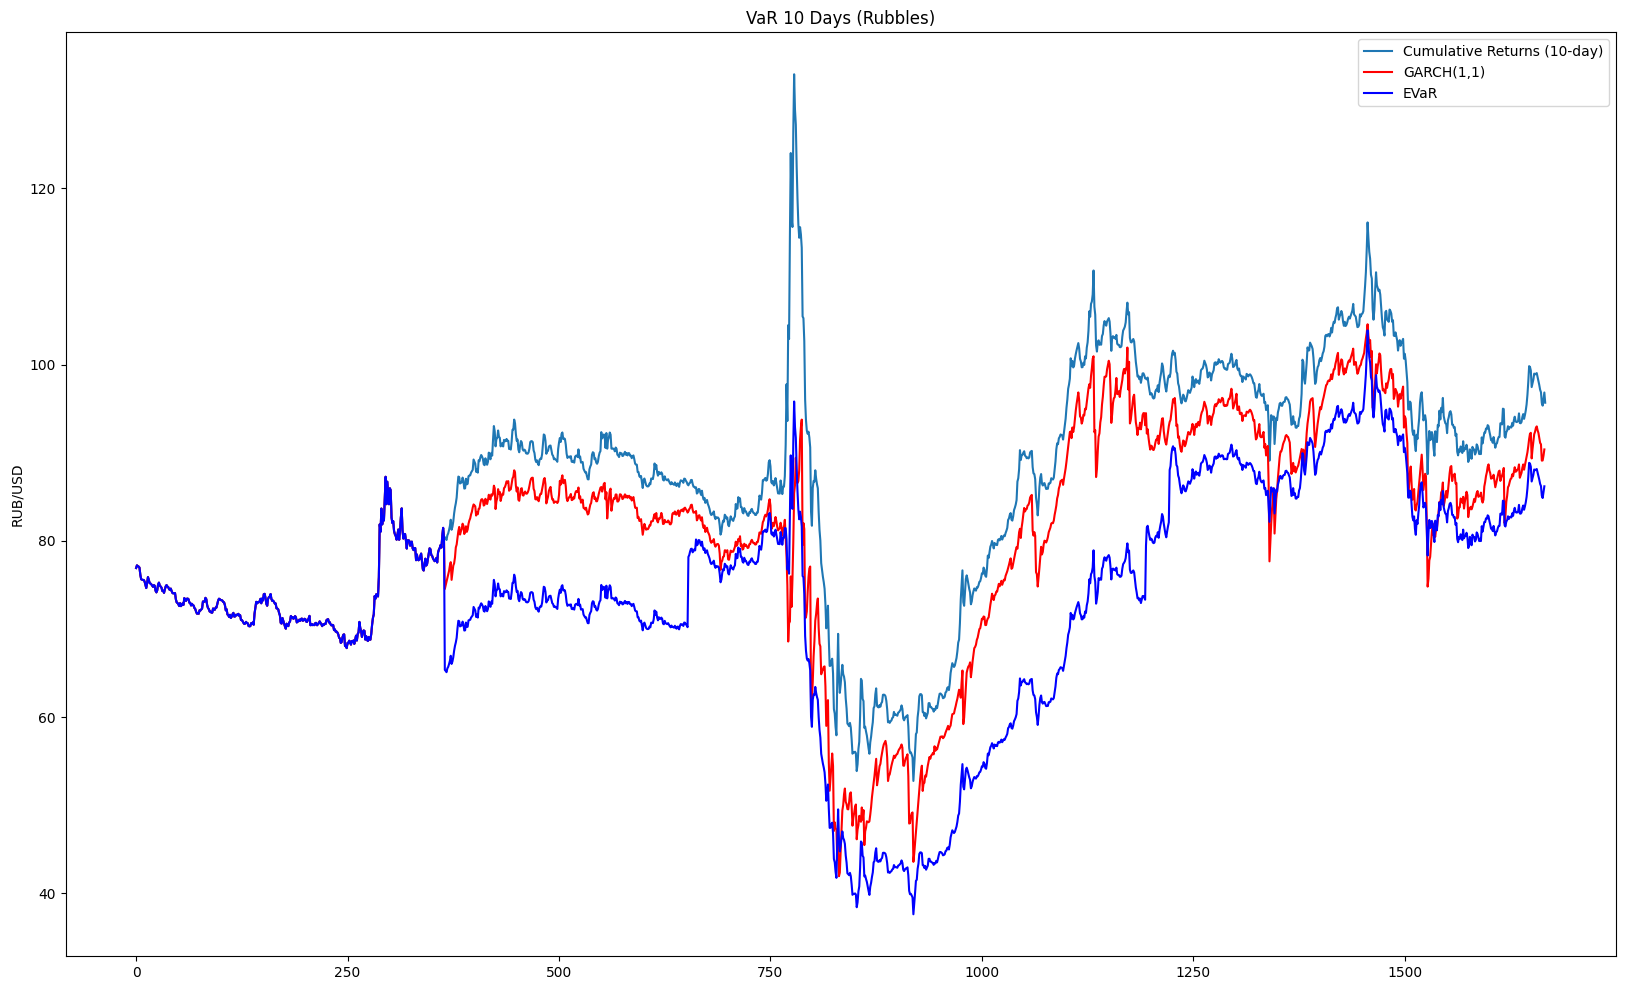

In [30]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_enthropic_vars, prices_usd), color='blue', label='EVaR')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()